In [74]:
#загружаем файл
import pandas as pd
df = pd.read_csv("train (6).csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
#смотрим, какие признаки нам подойдут
num_df = df.select_dtypes(include=["number"]) #только числ колонки
corr_matrx = num_df.corr()
saleprice = corr_matrx["SalePrice"].sort_values(ascending=False)

print(saleprice.head(7))

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
1stFlrSF       0.605852
Name: SalePrice, dtype: float64


In [29]:
#выбираем полезные признаки
features = ["GrLivArea", "GarageCars", "TotRmsAbvGrd", "OverallQual", "TotalBsmtSF",
           "YearBuilt", "FullBath"]
#OverallQual - качество дома от 1 до 10
#TotRmsAbvGrd - кол-во комнат

X = df[features].copy()
y = df["SalePrice"]

print(X.isna().sum()) #смотрим, есть ли пропуски

GrLivArea       0
GarageCars      0
TotRmsAbvGrd    0
OverallQual     0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
dtype: int64


In [30]:
#переходим к метрикам и моделям
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. Делим выборку на Обучающую (Train) и Валидационную (Val) - 80% на 20%
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Масштабируем признаки (StandardScaler - среднее в 0, шаг в 1 сигму)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#3. Обучаем обычную Линейную Регрессию (без регуляризации)
model_scaler = LinearRegression()
model_scaler.fit(X_train_scaled, y_train)

# 4. Обучаем Ridge-регуляризацию (L2-штраф)
model_ridge = Ridge(alpha=1.0) #alpha - сила штрафа
model_ridge.fit(X_train_scaled, y_train)

#5 Lasso (L1) на отмасштабированных данных
model_lasso = Lasso(alpha=100.0, random_state=42)
model_lasso.fit(X_train_scaled, y_train)

# 6. Делаем предсказания стоимости домов на валидации
y_pred_scaler = model_scaler.predict(X_val_scaled)
y_pred_ridge = model_ridge.predict(X_val_scaled)
y_pred_lasso = model_lasso.predict(X_val_scaled)

print("RMSE для обыч лин регр:", np.sqrt(mean_squared_error(y_val, y_pred_scaler)))
print("MAE для обыч лин регр:", mean_absolute_error(y_val, y_pred_scaler))
print("MAPE:", mean_absolute_percentage_error(y_val, y_pred_scaler))

print("---------")

print("RMSE для lasso:",np.sqrt(mean_squared_error(y_val, y_pred_lasso)))
print("MAE для lasso:", mean_absolute_error(y_val, y_pred_lasso))
print("MAPE:", mean_absolute_percentage_error(y_val, y_pred_lasso))

print("---------")

print("RMSE для Ridge:", np.sqrt(mean_squared_error(y_val, y_pred_ridge)))
print("MAE для Ridge:", mean_absolute_error(y_val, y_pred_ridge))
print("MAPE:", mean_absolute_percentage_error(y_val, y_pred_ridge))

print("--- ВЕСА ПРИЗНАКОВ В LASSO ---")
for feat, weight in zip(features, model_lasso.coef_):
    print(f"{feat:12} : {weight:.2f}")


# с помощью лин регр получили, что примерно на 25к долларов стоимость дома будет отилчаться
# от средней цены, то есть либо 25к баксов, либо 15% как удобнее говорить

RMSE для обыч лин регр: 39715.99129350281
MAE для обыч лин регр: 25318.95643242718
MAPE: 0.15285012802728024
---------
RMSE для lasso: 39741.51451394812
MAE для lasso: 25315.434513894375
MAPE: 0.15271105883955738
---------
RMSE для Ridge: 39721.483854419246
MAE для Ridge: 25317.29144610746
MAPE: 0.15281421606909823
--- ВЕСА ПРИЗНАКОВ В LASSO ---
GrLivArea    : 26877.24
GarageCars   : 11296.49
TotRmsAbvGrd : 103.67
OverallQual  : 28028.55
TotalBsmtSF  : 10805.17
YearBuilt    : 10555.64
FullBath     : -2576.08


In [47]:
#переходим к случ лесу rf
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, 
                                 max_depth=15)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

print(f"RMSE для Random Forest: {np.sqrt(mean_squared_error(y_val, y_pred_rf)):.2f}")
print(f"MAE для Random Forest:  {mean_absolute_error(y_val, y_pred_rf):.2f}")
print(f"MAPE для Random Forest: {mean_absolute_percentage_error(y_val, y_pred_rf) * 100:.2f}%")

RMSE для Random Forest: 29132.74
MAE для Random Forest:  18850.50
MAPE для Random Forest: 11.97%


In [62]:
#теперь переходим к град бустингу
from catboost import CatBoostRegressor
features_cat = ["GrLivArea", "GarageCars", "TotRmsAbvGrd", 
                "OverallQual", "TotalBsmtSF", "YearBuilt", "FullBath", "Neighborhood"]
X_cat = df[features_cat]
y_cat = df["SalePrice"]

# Переразбиваем, чтобы внутри X_train снова был текст
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_cat, y_cat, test_size=0.2,
                                                         random_state=42)
model_cb = CatBoostRegressor(iterations=350, learning_rate=0.04,
                             depth=8, random_seed=42, verbose=0)

# 3. Передаем параметр cat_features, чтобы модель знала, где текстовая колонка
model_cb.fit(X_train_c, y_train_c, cat_features=['Neighborhood'])

y_pred_cb = model_cb.predict(X_val_c)

print(f"RMSE для CatBoost: {np.sqrt(mean_squared_error(y_val_c, y_pred_cb)):.2f}")
print(f"MAE для CatBoost:  {mean_absolute_error(y_val_c, y_pred_cb):.2f}")
print(f"MAPE для CatBoost: {mean_absolute_percentage_error(y_val_c, y_pred_cb) * 100:.2f}%")

RMSE для CatBoost: 26078.57
MAE для CatBoost:  17126.47
MAPE для CatBoost: 10.76%


In [63]:
df["SalePrice"].mean()

np.float64(180921.19589041095)

In [64]:
import pandas as pd

# Собираем реальные цены и предсказания CatBoost в одну красивую табличку
predictions_df = pd.DataFrame({
    'Реальная цена ($)': y_val_c.values,
    'Предсказанная цена CatBoost ($)': y_pred_cb.round(2),
    'Ошибка в долларах ($)': (y_val_c.values - y_pred_cb).round(2)
})

# Выводим первые 10 домов для наглядности
predictions_df.head(10)

,Реальная цена ($),Предсказанная цена CatBoost ($),Ошибка в долларах ($)
0,154500,139131.27,15368.73
1,325000,319148.27,5851.73
2,115000,116337.13,-1337.13
3,159000,162514.84,-3514.84
4,315500,296576.70,18923.30
5,75500,77129.53,-1629.53
6,311500,209088.88,102411.12
7,146000,147026.37,-1026.37
8,84500,76744.89,7755.11
9,135500,124446.43,11053.57


In [65]:
#теперь уже переходим к тестовому файлу, предсказываем стоимость дома
df_test = pd.read_csv("test (1).csv")
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [66]:
X_test_final = df_test[features_cat]
#делаем предсказание нашей лучшей модели cb
y_test_pred = model_cb.predict(X_test_final)
submission = pd.DataFrame({
    "Id": df_test["Id"],       # Обязательно берем ID домов из тестового файла
    "SalePrice": y_test_pred   # Подставляем наши предсказания CatBoost
})

# 5. Сохраняем в файл без индексов строк
submission.to_csv("my_submission.csv", index=False)

print("Файл my_submission.csv успешно создан! Можно отправлять.")

Файл my_submission.csv успешно создан! Можно отправлять.


In [68]:
#проверим, как повлияет на результат логарифмирование
import numpy as np
y_train_log = np.log1p(y_train_c)
y_val_log = np.log1p(y_val_c)

# 2. Обучаем CatBoost на логарифмах (параметры берем твои лучшие)
model_cb_log = CatBoostRegressor(iterations=350, learning_rate=0.04, depth=6, random_seed=42, verbose=0)
model_cb_log.fit(X_train_c, y_train_log, cat_features=['Neighborhood'])

# 3. Делаем предсказание (оно тоже будет в логарифмах)
y_pred_log = model_cb_log.predict(X_val_c)

# 4. Возвращаем предсказания в реальные доллары через экспоненту
y_pred_final_dollars = np.expm1(y_pred_log)

print("=== CATBOOST С ЛОГАРИФМИРОВАНИЕМ ===")
print(f"MAPE в долларах: {mean_absolute_percentage_error(y_val_c, y_pred_final_dollars) * 100:.2f}%")
print(f"MAE в долларах:  {mean_absolute_error(y_val_c, y_pred_final_dollars):.2f}")

=== CATBOOST С ЛОГАРИФМИРОВАНИЕМ ===
MAPE в долларах: 10.59%
MAE в долларах:  17484.69


In [71]:
# 1. Загружаем тестовый файл
df_test = pd.read_csv("test (1).csv")
X_test_final = df_test[features_cat]

# 2. Делаем предсказание моделью, которая училась на логарифмах
y_test_pred_log = model_cb_log.predict(X_test_final)

# 3. Возвращаем предсказания из логарифмов в нормальные доллары через экспоненту!
y_test_pred_final = np.expm1(y_test_pred_log)

# 4. Сохраняем файл для Kaggle
submission_log = pd.DataFrame({
    "Id": df_test["Id"],
    "SalePrice": y_test_pred_final
})

submission_log.to_csv("my_submission_log.csv", index=False)
print("Файл my_submission_log.csv готов к отправке!")

Файл my_submission_log.csv готов к отправке!


In [72]:
import pandas as pd

# 1. Делаем предсказание для ВАЛИДАЦИОННОЙ выборки (оно в логарифмах)
y_val_pred_log = model_cb_log.predict(X_val_c)

# 2. Переводим предсказание обратно в обычные доллары
y_val_pred_dollars = np.expm1(y_val_pred_log)

# 3. Собираем всё в одну красивую таблицу
check_df = pd.DataFrame({
    'Реальная цена ($)': y_val_c.values,
    'Предсказание с логарифмом ($)': y_val_pred_dollars.round(2),
    'Ошибка в баксах ($)': (y_val_c.values - y_val_pred_dollars).round(2),
    'Ошибка в % (MAPE)': (abs(y_val_c.values - y_val_pred_dollars) / y_val_c.values * 100).round(2)
})

# 4. Выводим случайные 10 домов, чтобы посмотреть на разные ценовые категории
check_df.sample(10, random_state=42)

,Реальная цена ($),Предсказание с логарифмом ($),Ошибка в баксах ($),Ошибка в % (MAPE)
84,149500,146455.77,3044.23,2.04
260,395000,325874.15,69125.85,17.50
45,117500,144996.17,-27496.17,23.40
176,113000,132685.23,-19685.23,17.42
143,136500,166712.37,-30212.37,22.13
125,137000,121801.02,15198.98,11.09
227,64500,90516.45,-26016.45,40.34
118,112000,150389.73,-38389.73,34.28
9,135500,126061.95,9438.05,6.97
90,153500,146803.18,6696.82,4.36


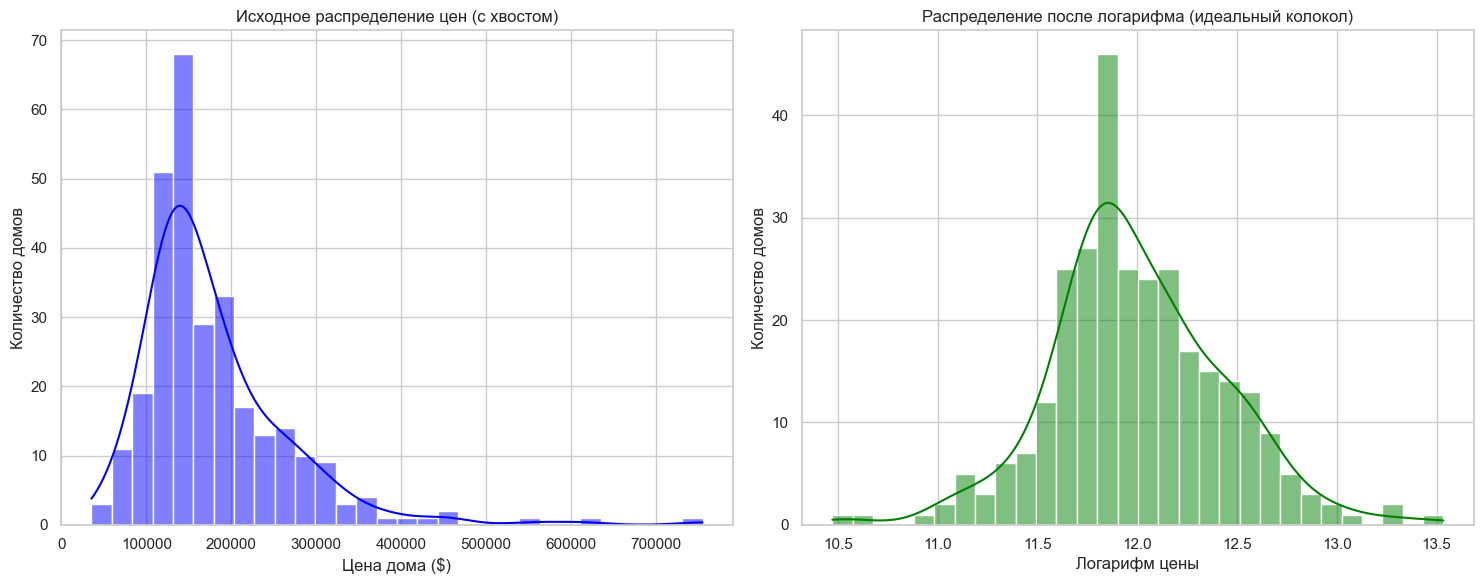

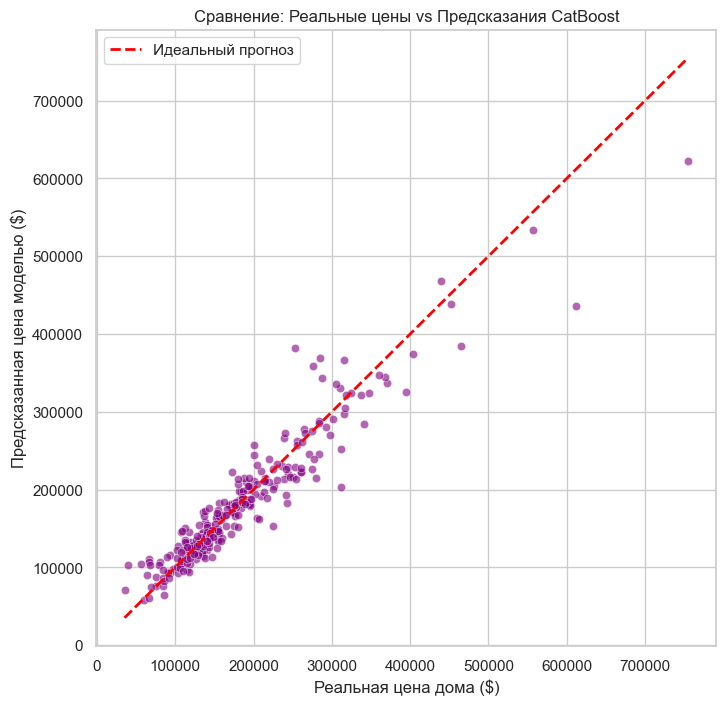

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем красивый стиль графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# ==========================================
# ГРАФИК 1: Распределение цен (До vs После логарифма)
# ==========================================
plt.subplot(1, 2, 1)
sns.histplot(y_val_c, kde=True, color="blue", bins=30)
plt.title("Исходное распределение цен (с хвостом)")
plt.xlabel("Цена дома ($)")
plt.ylabel("Количество домов")

plt.subplot(1, 2, 2)
# y_val_log у нас уже посчитан в коде выше
sns.histplot(y_val_log, kde=True, color="green", bins=30)
plt.title("Распределение после логарифма (идеальный колокол)")
plt.xlabel("Логарифм цены")
plt.ylabel("Количество домов")

plt.tight_layout()
plt.show()

# ==========================================
# ГРАФИК 2: Реальные цены против Предсказанных (Идеальная линия)
# ==========================================
plt.figure(figsize=(8, 8))

# Рисуем точки (каждая точка — один дом)
# y_val_pred_dollars — наши финальные предсказания в долларах
sns.scatterplot(x=y_val_c, y=y_val_pred_dollars, alpha=0.6, color="purple")

# Рисуем идеальную диагональную линию (если бы модель угадывала на 100% точно)
ideal_line = [y_val_c.min(), y_val_c.max()]
plt.plot(ideal_line, ideal_line, color="red", linestyle="--", linewidth=2, label="Идеальный прогноз")

plt.title("Сравнение: Реальные цены vs Предсказания CatBoost")
plt.xlabel("Реальная цена дома ($)")
plt.ylabel("Предсказанная цена моделью ($)")
plt.legend()
plt.show()